# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a Random Forest Classifier model will be used on a new data set based on Students' Social Media Addiction (https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships). This is a survey in which students from countries around the world, such as Bangladesh, India, USA, UK, Canada, Australia, Germany, Brazil, Japan, South Korea to find information about them such as their Academic level, Country, Average Daily Hours Spent, Most Used Platform, Sleep Hours Per Night etc. This notebook will plot points on a graph based on the columns Average Daily Hours Spent on social media (Avg_Daily_Usage_Hours) and Average Sleep Hours Per Night (Sleep_Hours_Per_Night) and then classifying them based on each survey responders most used social media platform.

## Questions:
By plotting the previously mentioned columns and classifying them, the questions that may be answered are:
##### Can You Tell What Social Media Platform Someone Uses Most Based On Their Average Sleep Hours And Average Time Spent On Social Media?
##### What Are The Worst Social Media Platforms In Terms Of Affecting Sleep?


## Setting Up Data
In the cell below, the necessary imports are made and the data from the columns, Sleep_Hours_Per_Night and Avg_Daily_Usage_Hours are read and placed into a 2d array to act as coordinates for plotting the data.

In [17]:
import numpy as np #Setting up imports
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as ptch 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

df = pd.read_csv('StudentsSocialMediaAddiction.csv').dropna() #Dropping columns with missing data and reading the dataset 
instant_messaging_apps = ["WhatsApp", "WeChat", "LINE", "KakaoTalk", "LinkedIn", "Snapchat"] #Excluding instant messaging apps and LinkedIn
df = df[~df['Most_Used_Platform'].isin(instant_messaging_apps)]

sleepHours = df['Sleep_Hours_Per_Night'].values
avgDailyHours = df['Avg_Daily_Usage_Hours'].values
mostUsedPlatforms = df['Most_Used_Platform'].values

plt.style.use('seaborn-v0_8-whitegrid')
coordinates = np.column_stack((avgDailyHours, sleepHours)) #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Score

Here the platform colours are set by creating a dictionary and also a custom colour map is made based on the assigned colours to use when visualising the predicted regions for different points of the graph. A legend is also added to make it easier to know which platforms are represented by the dots.

['Facebook', 'Instagram', 'TikTok', 'Twitter', 'VKontakte', 'YouTube']


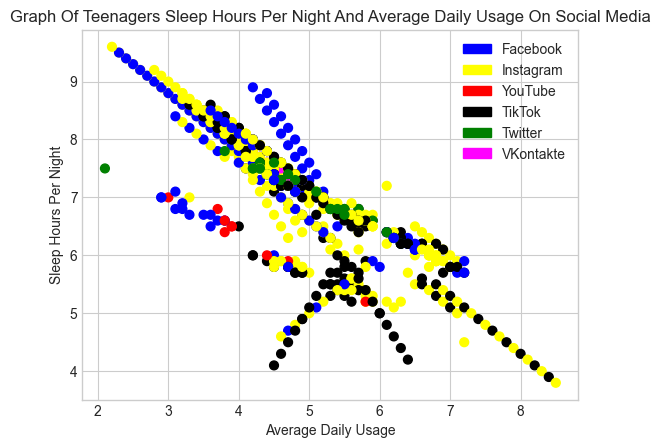

In [18]:
platform_colours = { #Assigning colours to each region
    "Facebook":"Blue",
    "Instagram":"Yellow",
    "TikTok":"Black",
    "Twitter":"Green",
    "VKontakte":"Magenta",
    "YouTube":"Red"
}

le = LabelEncoder()
numerical_platforms = le.fit_transform(df['Most_Used_Platform'])  #Converting categorical data (regions) to numerical format (Regions are listed alphabetically and then indexed)

platforms = list(le.classes_) #.classes holds the label for each category 
print(platforms)

ordered_colours = [platform_colours[p] for p in platforms]

custom_cmap = ListedColormap(ordered_colours)

def add_legend():
    region_patches=[
        ptch.Patch(color="Blue",label="Facebook"),
        ptch.Patch(color="Yellow",label="Instagram"),
        ptch.Patch(color="Red",label="YouTube"),
        ptch.Patch(color="Black",label="TikTok"),
        ptch.Patch(color="Green",label="Twitter"),
        ptch.Patch(color="Magenta",label="VKontakte"),]
    
    plt.legend(handles=region_patches,bbox_to_anchor=(1,1))

label_to_colour = {i: platform_colours[platform] for i, platform in enumerate(platforms)} #Assigning colours defined before to each region, enumerate(regions) gives an index for each region to index through
point_colours = [label_to_colour[i] for i in numerical_platforms]

# Plot scatter
plt.scatter(coordinates[:, 0], coordinates[:, 1], c=point_colours, s=40)

plt.xlabel('Average Daily Usage')
plt.ylabel('Sleep Hours Per Night')
plt.title('Graph Of Teenagers Sleep Hours Per Night And Average Daily Usage On Social Media')
add_legend()
plt.show()

## The Graph
The graph above depicts the points plotted with regards to the columns of the average sleep hours per night and the average daily hours spent on social media, both axes go from 0 to 10. The legend depicts the most used social media platform of each point.

## Training The Model And Making and Visualising Predictions
The cell below shows a helper function for training a decision tree on as well as visualising the results but also using bagging to create an ensemble of decision trees to create a random forest for better classifications as decision trees tend to overfit, however by combining multiple overfitting estimators, a better classification can be made. A 200 evenly spaced points of both axes are used to create a 2 dimensional grid, which the model will make predictions on, to see where the model would predict what social platforms belong to different parts of the graph. This is visualised by the filled in areas of the graph that match their assigned social media colour from the legend on the graph.

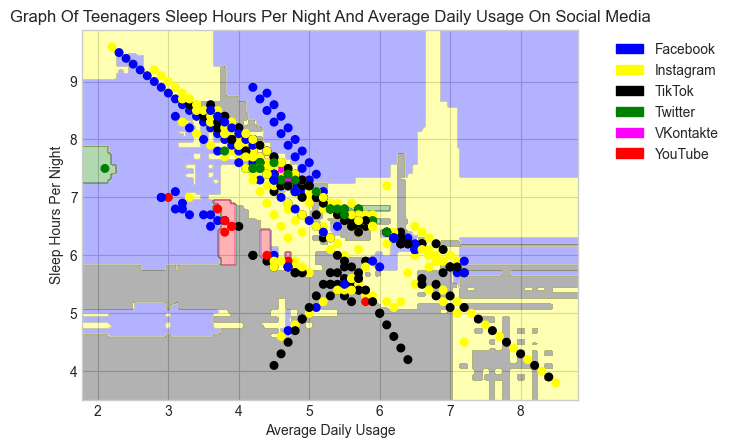

In [19]:
def visualize_classifier(model, X, y, ax=None, label_names=None):
    ax = ax or plt.gca() #Getting plot axes
    
    # Plot the training points
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=custom_cmap, #Scattering coordinates passed in and using custom colour map
                    clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight') #Resizing subplots to try and prevent overlap between labels on axes and axes objects
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Fit model
    model.fit(X, y) #Fitting model on plotted points and classifier
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200), #Creating a meshgrid (2D grid of points) out of 200 evenly spaced points between axes limits to see where the model predicts everywhere on the graph
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) #Making predictions after reshaping the x and y coordinates of the meshgrid 

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, #Drawing contour lines and filling in colours
                levels=np.arange(len(np.unique(y)) + 1) - 0.5,
                cmap=custom_cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)
    
    if label_names is not None: #Adding a legend for the visualisation of the graph
        unique_labels = np.unique(y) #Getting unique labels/platform names
        cmap_obj = plt.get_cmap(custom_cmap)

        legend_patches = [ #Creating patches for the legend based on the labels and their assigned colours 
            ptch.Patch(color=cmap_obj(label / (len(unique_labels)-1)),
                  label=label_names[label])
            for label in unique_labels
        ]

        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xlabel('Average Daily Usage')
        plt.ylabel('Sleep Hours Per Night')
        plt.title('Graph Of Teenagers Sleep Hours Per Night And Average Daily Usage On Social Media')

bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, max_samples=0.8, #Using bagging for an ensemble of decision trees to create a random forest for better classifications
                        random_state=1)

bag.fit(coordinates, numerical_platforms) 
#visualize_classifier(DecisionTreeClassifier(), coordinates, numerical_platforms,label_names=platforms)
visualize_classifier(bag, coordinates, numerical_platforms,label_names=platforms) #Visualising the results of the random forest

## Graph And Platform Predictions Of Randomised Points
The graph has many elongated lines, potentially due to the large amount of overlap between points, particularly where users spend about 4 to 5 hours on social media platforms on average. However on the lower ranges of sleep, it's predicted that TikTok clusters tend to take up the most space from average daily usages of 2 to 7 hours which may speak to the addictive nature of short form content. 

Instagram tends to be spread out in comparison but its predictions still cluster on the heavier average usage hours of 7 to 8 but still have clusters the particularly lower hours of sleep which may still show off its addictiveness.

The predictions for FaceBook tends to cluster between some Instagram and TikTok clusters but also have predictions that go high into the average sleep hours per night, indicating that it may not be as addictive in comparison to TikTok and Instagram due to the lack of effect on sleep but may still however have some effect given the smaller Facebook clusters in the lower sleep hours and can also prove to be addictive due to the cluster in the 7 to 8 average daily usage.

Twitter and YouTube have far smaller clusters in comparison to the three mentioned previously, having about four clusters between them. There may be implications that these specific platforms are not as addictive due to the clusters never going past 5 hours of average daily usage of social media if either of these platforms are a users most used social media platform yet poor sleeping habits still show for the YouTube clusters given that the few that are seen appear in the less than 7 hour range aside from Twitter.

## Evaluating The Model
When evaluating the model by splittin the training and test sets, however a new helper function for visualisation is created where the function only predicts rather than fits beforehand. This is so the bag can be trained on training data and then the bag can make a prediction on the test data which the function will visualise.

In [20]:
def visualize_classifier_without_fit(model, X, y, ax=None, label_names=None):
    ax = ax or plt.gca() #Getting plot axes
    
    # Plot the training points
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=custom_cmap, #Scattering coordinates passed in and using custom colour map
                    clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight') #Resizing subplots to try and prevent overlap between labels on axes and axes objects
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(*xlim, num=200), #Creating a meshgrid (2D grid of points) out of 200 evenly spaced points between axes limits to see where the model predicts everywhere on the graph
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape) #Making predictions after reshaping the x and y coordinates of the meshgrid 

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, #Drawing contour lines and filling in colours
                levels=np.arange(len(np.unique(y)) + 1) - 0.5,
                cmap=custom_cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)
    
    if label_names is not None: #Adding a legend for the visualisation of the graph
        unique_labels = np.unique(y) #Getting unique labels/platform names
        cmap_obj = plt.get_cmap(custom_cmap)

        legend_patches = [ #Creating patches for the legend based on the labels and their assigned colours 
            ptch.Patch(color=cmap_obj(label / (len(unique_labels)-1)),
                  label=label_names[label])
            for label in unique_labels
        ]

        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xlabel('Average Daily Usage')
        plt.ylabel('Sleep Hours Per Night')
        plt.title('Teenagers Sleep Hours Per Night And Average Daily Usage On Social Media Categorised By Platform')


The cell shows the results of the train test split. The predictions made using the test set, shows that some points are definitely predicted poorly given that points of a different colour show in predicted regions where a different platform is predicted such as TikTok showing up in the YouTube region.

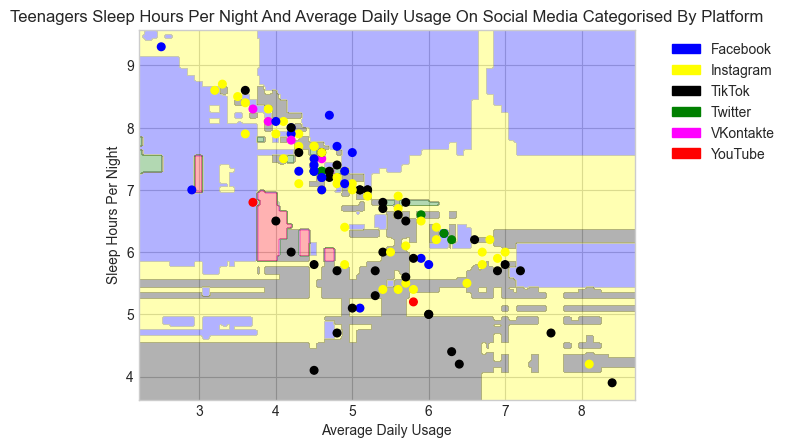

In [21]:
X_train, X_test, y_train, y_test = train_test_split(coordinates, numerical_platforms, test_size=0.2, random_state=42) # Split data into 80% training and 20% test set

bag = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    random_state=1
)

bag.fit(X_train, y_train)

y_pred = bag.predict(X_test)

visualize_classifier_without_fit(bag, X_test, y_test, label_names=platforms)
plt.show()

The classification report below shows the accuracy classication report. The classification report generated shows that there is a low precision (Correct Predictions Made) and recall (The Number Of Labels Predicted Correctly) for when the model predicts a student's most used social media platform based on average hours spent on social media and average hours spent sleeping per night, it has a precision of 0.36 at most and a recall of 0.43 and the f1 score, a mix of both the accuracy and recall also seems to be very poor at 0.39, which represents a mix of both precision and recall with an f1 score of 0.39 for Instagram, which also is the classifier that the model predicted best. This may be due to how close all social media platforms are together on the graph which may affect the model's accuracy, which is very low at 0.32 or 32%.

In [22]:
report = classification_report(y_test, y_pred, labels=range(len(le.classes_)), target_names=le.classes_, zero_division=0) #Getting Classification Report
print(report)

              precision    recall  f1-score   support

    Facebook       0.29      0.23      0.26        22
   Instagram       0.36      0.43      0.39        44
      TikTok       0.31      0.34      0.33        38
     Twitter       0.00      0.00      0.00         6
   VKontakte       0.00      0.00      0.00         4
     YouTube       0.00      0.00      0.00         2

    accuracy                           0.32       116
   macro avg       0.16      0.17      0.16       116
weighted avg       0.29      0.32      0.30       116



The confusion matrix below shows the predictions made by the model. It seems clear that many of the most used social media platforms are either TikTok or Instagram and due to how close the two points usually are on the graph, it appears that the model often mistakens one for the other about half the time. It also doesn't seem to predict other social media platforms very accurately either as Facebook was only predicted correctly 5 out of 22 times.

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Facebook'),
  Text(1, 0, 'Instagram'),
  Text(2, 0, 'TikTok'),
  Text(3, 0, 'Twitter'),
  Text(4, 0, 'VKontakte'),
  Text(5, 0, 'YouTube')])

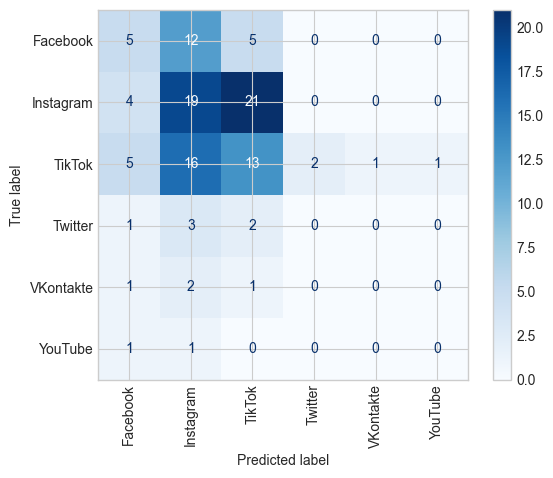

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_) #creating confusion matrix with the labels as the label encoder's classes
cm_display.plot(cmap=plt.cm.Blues)  
plt.xticks(rotation=90)

## Conclusion 
In conclusion, it seems that users with the lowest average sleep hours and highest average time spent on social media appears to be between TikTok and Instagram according to the model. The model's TikTok predictions however, cluster around the bottom half of the graph, with a large cluster in the 4 to 5 average hours of sleep, therefore making it the worst platform for negatively affecting the sleep of its users. In the bottom right, where users would have a lower average hours of sleep and also a high average daily hours spent on social media, both Instagram and TikTok form clusters there. However, Instagram clusters all around the graph, meaning that it may not be that harmful to its users in comparison to TikTok with most of its clusters at the bottom of the half of the average number of hours of sleep. Due to the model's poor accuracy in its predictions, it seems to be difficult  to predict a student's most used social media platform based on their average daily usage of social media and also their average number of hours of sleep per night.